# Explorar el Lakehouse Medallion

Este notebook lee directamente las tres capas del lago de datos:

- **Bronze** y **Silver**: tablas Delta "crudas" en `data_lakehouse/`, escritas por los jobs de Spark.
- **Gold**: tablas Delta creadas por dbt, ubicadas en `dbt_project/spark-warehouse/`.

La configuracion de Spark (extensiones y catalogo de Delta, paquete Maven a resolver via Ivy)
ya viene dada por `spark/conf/spark-defaults.conf` (montado en `SPARK_CONF_DIR`), asi que
alcanza con crear una SparkSession comun.

In [1]:
import os

from pyspark.sql import SparkSession

LAKEHOUSE_PATH = os.environ.get("LAKEHOUSE_PATH", "/opt/data_lakehouse")
DBT_WAREHOUSE_PATH = "/opt/dbt_project/spark-warehouse"

spark = (
    SparkSession.builder
    .appName("explorar_medallion")
    .master("local[*]")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
spark

:: loading settings :: url = jar:file:/usr/local/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
io.delta#delta-spark_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-35b8d3eb-484a-4f7c-b628-62c0d05c4b7a;1.0
	confs: [default]
	found io.delta#delta-spark_2.12;3.2.0 in central
	found io.delta#delta-storage;3.2.0 in central
	found org.antlr#antlr4-runtime;4.9.3 in central
:: resolution report :: resolve 118ms :: artifacts dl 3ms
	:: modules in use:
	io.delta#delta-spark_2.12;3.2.0 from central in [default]
	io.delta#delta-storage;3.2.0 from central in [default]
	org.antlr#antlr4-runtime;4.9.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------------------------------------------------
	|      default     |   3   |   0   |   0   |   

26/09/11 21:43:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/11 21:43:02 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


## Bronze — eventos crudos (append-only)

In [2]:
bronze_df = spark.read.format("delta").load(f"{LAKEHOUSE_PATH}/bronze/ventas")
print(f"Filas en Bronze: {bronze_df.count()}")
bronze_df.printSchema()
bronze_df.orderBy(bronze_df.timestamp.desc()).limit(20).toPandas()

26/09/11 21:43:08 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Filas en Bronze: 4281
root
 |-- tx_id: string (nullable = true)
 |-- cliente_id: string (nullable = true)
 |-- producto: string (nullable = true)
 |-- sku: string (nullable = true)
 |-- precio: double (nullable = true)
 |-- cantidad: integer (nullable = true)
 |-- tipo_operacion: string (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- kafka_timestamp: timestamp (nullable = true)
 |-- ingestion_timestamp: timestamp (nullable = true)



,tx_id,cliente_id,producto,sku,precio,cantidad,tipo_operacion,timestamp,kafka_timestamp,ingestion_timestamp
0,bc532f94-250c-47a0-abac-96ae824810db,CLI-3358,Auriculares BT,SKU-005,62973.32,2,INSERT,2026-09-11T21:43:09.047426+00:00,2026-09-11 21:43:09.048,2026-09-11 21:43:10.027
1,92a523a1-7f83-435d-b5d1-814a7f64a5ce,CLI-4576,Notebook Pro 14,SKU-001,935007.13,2,INSERT,2026-09-11T21:43:08.041556+00:00,2026-09-11 21:43:08.045,2026-09-11 21:43:10.027
2,ec4a664f-b123-4b33-8463-27f1fbaee8db,CLI-7611,Mouse Inalambrico,SKU-002,15494.01,4,DELETE,2026-09-11T21:43:07.040250+00:00,2026-09-11 21:43:07.040,2026-09-11 21:43:10.027
3,39423b07-a092-42d2-aace-8e7f0f3f940d,CLI-6464,Notebook Pro 14,SKU-001,938216.80,3,INSERT,2026-09-11T21:43:06.039460+00:00,2026-09-11 21:43:06.039,2026-09-11 21:43:10.027
4,0aba9ee0-1b06-459f-8e3f-17bdf868ec0b,CLI-1398,Teclado Mecanico,SKU-003,46389.33,3,DELETE,2026-09-11T21:43:05.038901+00:00,2026-09-11 21:43:05.039,2026-09-11 21:43:10.027
5,656418b5-726d-4e10-b6fc-c54e1029d551,CLI-5851,Teclado Mecanico,SKU-003,44056.08,5,DELETE,2026-09-11T21:43:04.038545+00:00,2026-09-11 21:43:04.038,2026-09-11 21:43:10.027
6,6d2c9c05-d5ea-49d3-bc2b-a7b2d1c9dd11,CLI-3643,Impresora Laser,SKU-010,173357.02,5,UPDATE,2026-09-11T21:43:03.038218+00:00,2026-09-11 21:43:03.038,2026-09-11 21:43:10.027
7,5d15e8b5-fce1-4ff0-81af-eadfb3ba42b2,CLI-3793,Silla Ergonomica,SKU-008,195235.37,3,INSERT,2026-09-11T21:43:02.037851+00:00,2026-09-11 21:43:02.037,2026-09-11 21:43:10.027
8,ecf702af-2364-4636-9882-56d1914b8270,CLI-7922,Teclado Mecanico,SKU-003,42124.82,2,INSERT,2026-09-11T21:43:01.036647+00:00,2026-09-11 21:43:01.037,2026-09-11 21:43:10.027
9,8ffe9bc9-9fed-45ff-9361-2a01de9daf1b,CLI-6699,SSD NVMe 1TB,SKU-007,82224.31,2,INSERT,2026-09-11T21:43:00.036045+00:00,2026-09-11 21:43:00.036,2026-09-11 21:43:10.027


## Silver — limpio, deduplicado, con upserts/deletes aplicados

In [3]:
silver_df = spark.read.format("delta").load(f"{LAKEHOUSE_PATH}/silver/ventas")
print(f"Filas en Silver: {silver_df.count()}")
silver_pd = silver_df.toPandas()
silver_pd.head(20)

Filas en Silver: 1654


,tx_id,cliente_id,producto,sku,precio,cantidad,tipo_operacion,timestamp
0,0006691d-2a34-4035-aab8-54bcb31f5860,CLI-6194,Auriculares BT,SKU-005,60309.50,5,INSERT,2026-09-11T20:37:44.931121+00:00
1,000f35a9-85af-4f69-ac9a-1706a491b602,CLI-5094,Teclado Mecanico,SKU-003,41080.65,1,UPDATE,2026-09-11T20:53:08.333259+00:00
2,00225c58-4ec9-4bd0-ac55-405da761ed55,CLI-9023,SSD NVMe 1TB,SKU-007,84785.54,2,INSERT,2026-09-11T21:08:31.736296+00:00
3,00348c6a-5ed9-446f-bf15-f65f9e6c27c7,CLI-1013,Webcam HD,SKU-006,27094.70,3,INSERT,2026-09-11T21:28:16.572555+00:00
4,00465ee1-f18e-40af-b36e-1da68a7254c0,CLI-8426,Hub USB-C,SKU-009,21208.24,3,INSERT,2026-09-11T21:07:04.503920+00:00
5,0046689c-50d4-491b-994b-2a9f6f65c708,CLI-4273,Webcam HD,SKU-006,27022.02,2,INSERT,2026-09-11T20:42:56.938612+00:00
6,00576218-adc3-49f8-bc96-d589ed813618,CLI-5589,Hub USB-C,SKU-009,20287.51,1,INSERT,2026-09-11T20:42:22.813095+00:00
7,0094eda5-caf2-4dc3-a2de-207600f74040,CLI-2650,Impresora Laser,SKU-010,176197.78,1,INSERT,2026-09-11T21:23:28.244828+00:00
8,00b43707-3ba4-46e1-ab59-0ad0a1e93748,CLI-1747,SSD NVMe 1TB,SKU-007,92965.13,4,INSERT,2026-09-11T21:00:06.522078+00:00
9,014b2d6a-9a25-4c70-9766-1ec6ec4a7662,CLI-7993,Impresora Laser,SKU-010,173291.00,3,INSERT,2026-09-11T21:19:13.552840+00:00


In [4]:
# Historial de versiones Delta: cada fila es un commit (los MERGE de CDC del batch de Silver)
spark.sql(f"DESCRIBE HISTORY delta.`{LAKEHOUSE_PATH}/silver/ventas`").select(
    "version", "timestamp", "operation", "operationMetrics"
).toPandas()

,version,timestamp,operation,operationMetrics
0,6,2026-09-11 21:30:17.271,MERGE,"{'numOutputRows': '1654', 'numTargetBytesAdded..."
1,5,2026-09-11 21:15:37.187,MERGE,"{'numOutputRows': '1215', 'numTargetBytesAdded..."
2,4,2026-09-11 21:00:18.155,MERGE,"{'numOutputRows': '822', 'numTargetBytesAdded'..."
3,3,2026-09-11 20:45:35.112,MERGE,"{'numOutputRows': '399', 'numTargetBytesAdded'..."
4,2,2026-09-11 20:44:17.908,MERGE,"{'numOutputRows': '358', 'numTargetBytesAdded'..."
5,1,2026-09-11 20:44:13.630,MERGE,"{'numOutputRows': '358', 'numTargetBytesAdded'..."
6,0,2026-09-11 20:41:17.444,WRITE,"{'numOutputRows': '276', 'numOutputBytes': '29..."


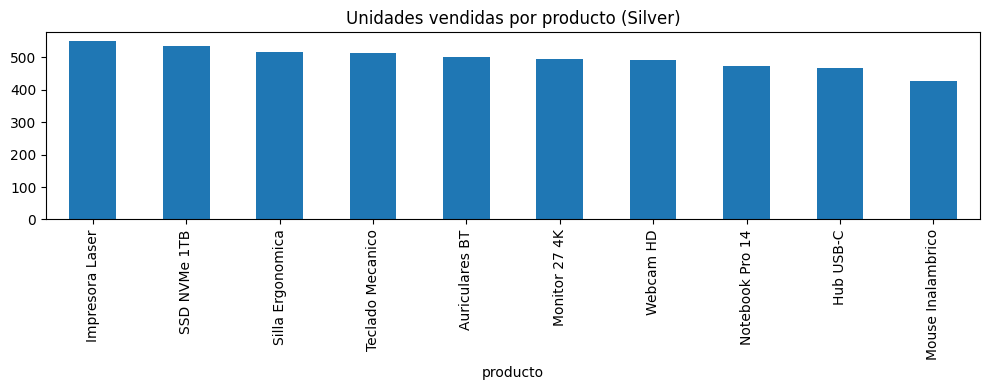

In [5]:
import matplotlib.pyplot as plt

silver_pd["cantidad"].groupby(silver_pd["producto"]).sum().sort_values(ascending=False).plot(
    kind="bar", figsize=(10, 4), title="Unidades vendidas por producto (Silver)"
)
plt.tight_layout()
plt.show()

## Gold — KPIs agregados (creados por dbt)

In [6]:
gold_ventas_df = spark.read.format("delta").load(f"{DBT_WAREHOUSE_PATH}/gold_kpi_ventas")
gold_ventas_pd = gold_ventas_df.orderBy("fecha").toPandas()
gold_ventas_pd

,fecha,cantidad_transacciones,clientes_unicos,unidades_vendidas,ingresos_totales,ticket_promedio
0,2026-09-11,1654,1508,4961,9.489710e+08,573743.04


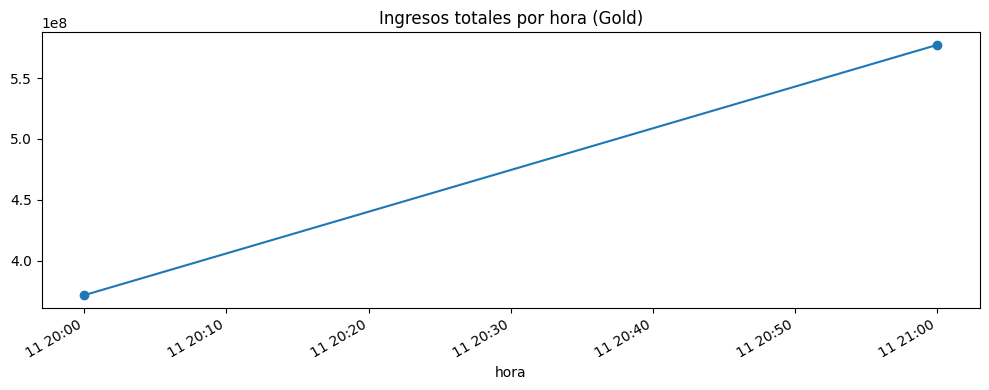

,hora,cantidad_transacciones,clientes_unicos,unidades_vendidas,ingresos_totales,ticket_promedio
0,2026-09-11 20:00:00,688,658,2055,3.716670e+08,540213.67
1,2026-09-11 21:00:00,966,911,2906,5.773040e+08,597623.17


In [7]:
gold_ventas_hora_df = spark.read.format("delta").load(f"{DBT_WAREHOUSE_PATH}/gold_kpi_ventas_hora")
gold_ventas_hora_pd = gold_ventas_hora_df.orderBy("hora").toPandas()

gold_ventas_hora_pd.plot(
    x="hora", y="ingresos_totales", marker="o", figsize=(10, 4),
    title="Ingresos totales por hora (Gold)", legend=False,
)
plt.tight_layout()
plt.show()
gold_ventas_hora_pd

In [8]:
gold_producto_df = spark.read.format("delta").load(f"{DBT_WAREHOUSE_PATH}/gold_kpi_producto")
gold_producto_pd = gold_producto_df.orderBy("ingresos_totales", ascending=False).toPandas()
gold_producto_pd

,producto,cantidad_transacciones,unidades_vendidas,ingresos_totales,precio_promedio
0,Notebook Pro 14,155,474,4.394660e+08,925634.43
1,Monitor 27 4K,164,494,1.825568e+08,369668.97
2,Silla Ergonomica,165,516,1.052018e+08,204362.62
3,Impresora Laser,184,549,9.375894e+07,170925.93
4,SSD NVMe 1TB,179,533,4.687493e+07,88147.50
5,Auriculares BT,161,501,2.920060e+07,58313.15
6,Teclado Mecanico,170,512,2.238625e+07,43867.74
7,Webcam HD,167,490,1.338359e+07,27259.43
8,Hub USB-C,154,466,9.942966e+06,21326.90
9,Mouse Inalambrico,155,426,6.199130e+06,14578.39


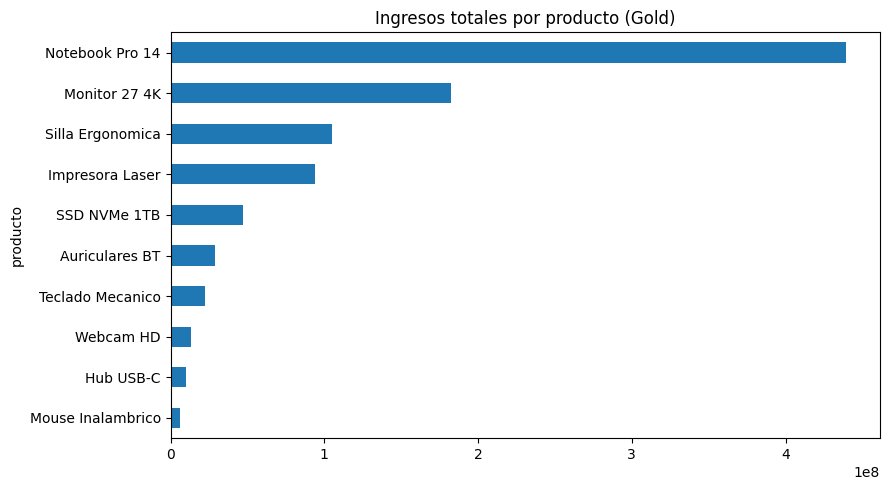

In [9]:
gold_producto_pd.plot(
    kind="barh", x="producto", y="ingresos_totales", figsize=(9, 5),
    title="Ingresos totales por producto (Gold)", legend=False,
)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## (Bonus) Espiar el topico de Kafka en crudo

Util para ver los eventos CDC tal cual los emite el productor, antes de que Spark los toque.

In [10]:
import json

from kafka import KafkaConsumer

consumer = KafkaConsumer(
    os.environ.get("KAFKA_TOPIC", "ventas_cdc"),
    bootstrap_servers=os.environ.get("KAFKA_BOOTSTRAP_SERVERS", "kafka:9092"),
    auto_offset_reset="latest",
    consumer_timeout_ms=5000,
    value_deserializer=lambda v: json.loads(v.decode("utf-8")),
)

for i, record in enumerate(consumer):
    print(record.value)
    if i >= 9:
        break

consumer.close()

{'tx_id': '5d15e8b5-fce1-4ff0-81af-eadfb3ba42b2', 'cliente_id': 'CLI-5672', 'producto': 'Notebook Pro 14', 'sku': 'SKU-001', 'precio': 979704.43, 'cantidad': 5, 'tipo_operacion': 'DELETE', 'timestamp': '2026-09-11T21:43:29.151078+00:00'}


{'tx_id': '2ea57e44-2bd0-4d29-958d-d47dde150693', 'cliente_id': 'CLI-2952', 'producto': 'SSD NVMe 1TB', 'sku': 'SKU-007', 'precio': 86677.19, 'cantidad': 1, 'tipo_operacion': 'DELETE', 'timestamp': '2026-09-11T21:43:30.153091+00:00'}


{'tx_id': '6d5f788e-9e86-4cef-a44e-55ae0bbfbac6', 'cliente_id': 'CLI-4782', 'producto': 'Notebook Pro 14', 'sku': 'SKU-001', 'precio': 960951.01, 'cantidad': 3, 'tipo_operacion': 'INSERT', 'timestamp': '2026-09-11T21:43:31.153730+00:00'}
